# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.

The dataset I selected contains information about 2,846 NFL players. Each row represents a player, and the columns include identifying information, physical attributes, and salary, which is my target feature (CapHit). To explore what influences salary, I compared it with five features: Age, Height, Weight, Years of Experience, and Position. The feature most related to salary is Years of Experience, since players with more experience usually make more money. Position also has a big impact, because some positions, like quarterback, are paid much higher than others. On the other hand, Height and Weight don’t show much effect on salary, and Age only has a small influence, with mid-career players often earning the most. Overall, the results show that what position a player has and how long they’ve been in the league are the biggest factors in determining salary.

In [7]:
import pandas as pd

# Load dataset
df = pd.read_csv("Master-Player-List.csv")

# Clean CapHit (remove $ and commas, convert to int)
df["CapHit"] = df["CapHit"].replace('[\$,]', '', regex=True).astype(int)

# Clean Height (convert "6-5" → inches)
def height_to_inches(h):
    if isinstance(h, str) and "-" in h:
        ft, inch = h.split("-")
        return int(ft) * 12 + int(inch)
    return None

df["HeightInches"] = df["Height"].apply(height_to_inches)

# Clean YrsExp (rookie = 0, otherwise number)
df["YrsExp"] = df["YrsExp"].replace("R", 0).astype(int)

df.head()

,PlayerID,Name,Team,Position,Height,Weight,DOB,Age,YrsExp,CapHit,HeightInches
0,ABrewerARI,Aaron Brewer,ARI,LS,6-5,232,7/5/1990,34,13,1152500,77
1,ABaccelliaARI,Andre Baccellia,ARI,WR,5-10,175,1/7/1997,27,2,985000,70
2,AChachereARI,Andre Chachere,ARI,DB,6-0,197,2/10/1996,28,4,1055000,72
3,APleasantsARI,Austen Pleasants,ARI,OT,6-7,330,8/22/1997,26,1,795000,79
4,BOjulariARI,B.J. Ojulari,ARI,LB,6-2,248,4/5/2002,22,2,1954003,74


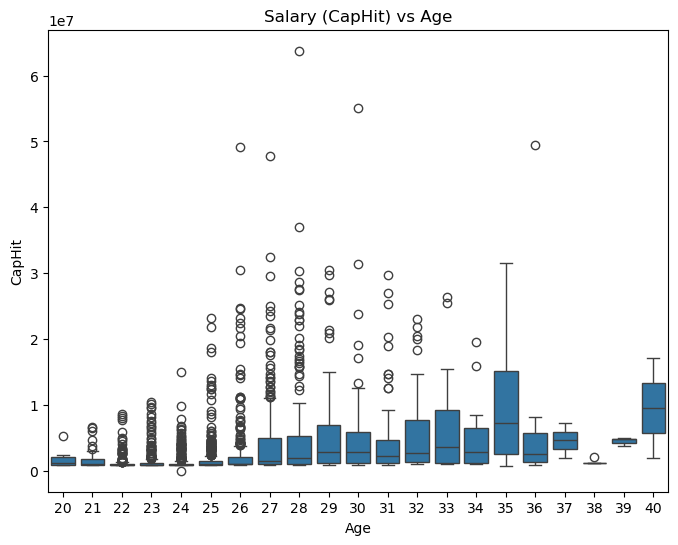

In [38]:
# Box Plot Salary vs Age
plt.figure(figsize=(8,6))
sns.boxplot(x="Age", y="CapHit", data=df)
plt.title("Salary (CapHit) vs Age")
plt.show()

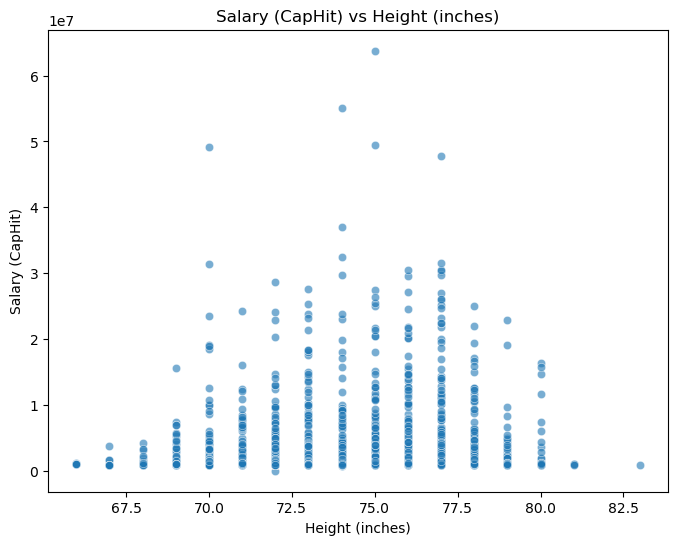

In [30]:
#Scatterplot Salary vs Height

sns.scatterplot(x="HeightInches", y="CapHit", data=df, alpha=0.6)
plt.title("Salary (CapHit) vs Height (inches)")
plt.xlabel("Height (inches)")
plt.ylabel("Salary (CapHit)")
plt.show()

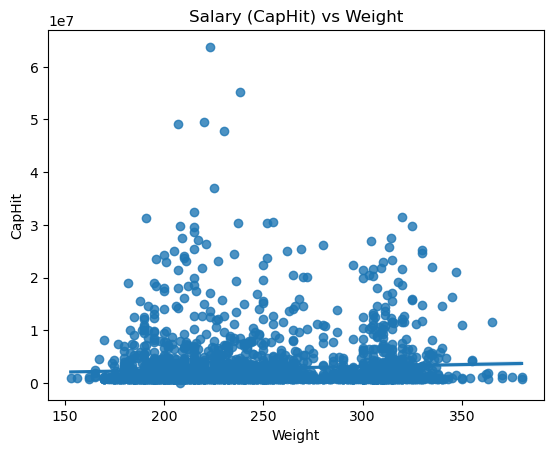

In [43]:
#Scatterplot Salary vs Years of Experience
sns.regplot(x="Weight", y="CapHit", data=df)
plt.title("Salary (CapHit) vs Weight")
plt.xlabel("Weight")
#plt.ylabel("Salary")
plt.show()

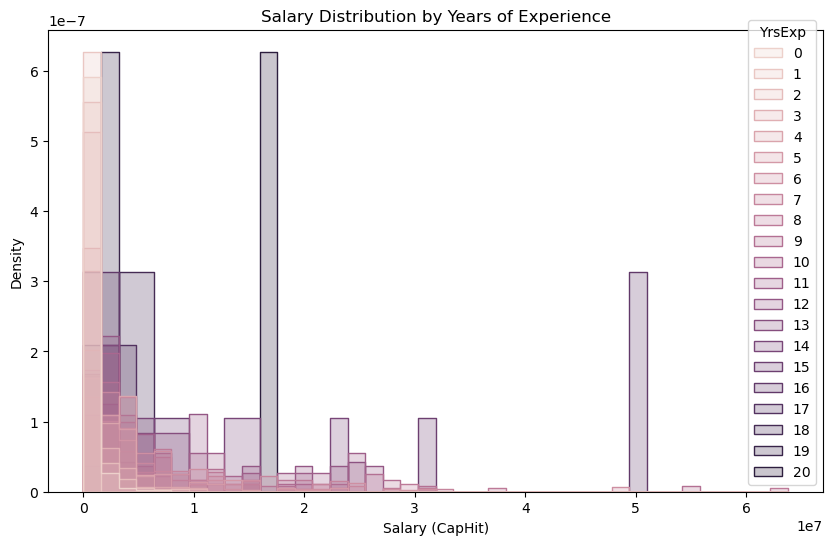

In [23]:
#Histogram of Salary by Years of Experience
sns.histplot(data=df, x="CapHit", hue="YrsExp", bins=40, element="step", stat="density", common_norm=False)
plt.title("Salary Distribution by Years of Experience")
plt.xlabel("Salary (CapHit)")
plt.show()

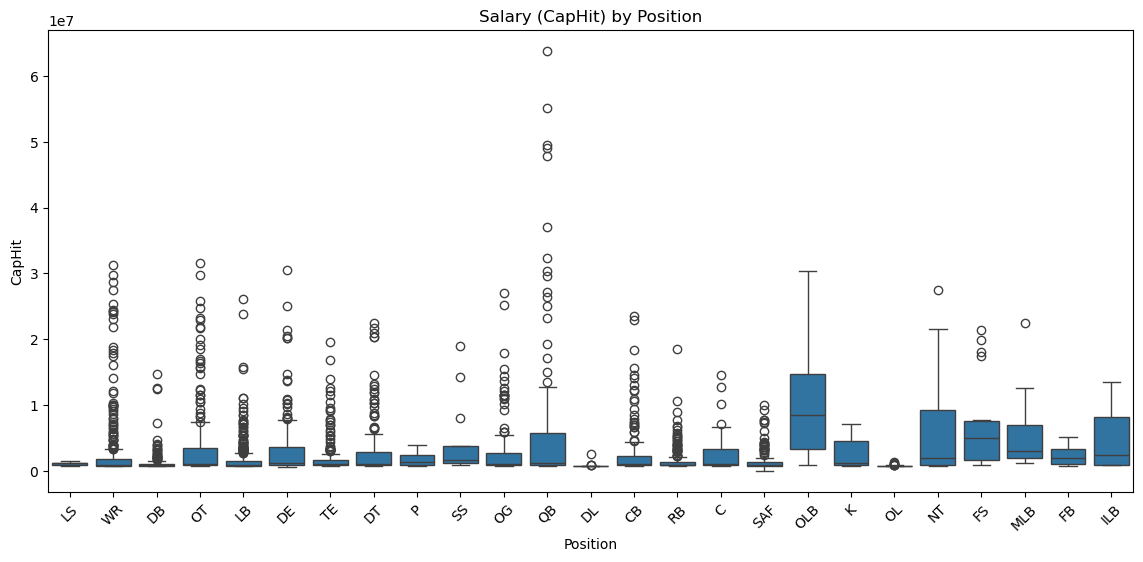

In [24]:
#Box Plot Salary by Position
sns.boxplot(x="Position", y="CapHit", data=df)
plt.xticks(rotation=45)
plt.title("Salary (CapHit) by Position")
plt.show()